<a href="https://colab.research.google.com/github/mathispernin/OSCD_ChangeDetection/blob/main/Copy_of_change_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Change Detection sur OSCD - Visual Computing Project

Ce notebook implémente et compare plusieurs algorithmes de détection de changement non supervisés sur le dataset OSCD (Onera Satellite Change Detection).

## Objectif du projet
Comparer les performances de plusieurs algorithmes classiques pour la détection de changements urbains par image satellite sur le dataset OSCD (CVA, PCA-Kmeans, IR-MAD, SiROC et IR-MAD avec Graph Cuts).

## Méthodologie Train / Test

Nous utilisons le dataset OSCD de l'Onera. Nous adoptons une démarche de validation en séparant les 24 locations du dataset en un ensemble d'entraînement (14 locations) et un ensemble de test (10 locations), afin que les métriques finales reportées reflètent une performance de généralisation non biaisée.
- **Train (14 locations)** : utilisé pour explorer les méthodes, comparer les approches, et optimiser les hyperparamètres (méthodes et valeurs pour les seuils, paramètres des méthodes, etc.).
- **Test (10 locations)** : évaluer la performance finale des méthodes sélectionnées sur des nouvelles données, en utilisant les hyperparamètres optimisés sur l'ensemble d'entraînement.

In [2]:
# 1. Clone the repo to get the data/scripts
!git clone https://github.com/mathispernin/OSCD_ChangeDetection.git

# 2. Move into the repo directory so imports/paths work
import os
os.chdir('OSCD_ChangeDetection')

# 3. Install any libraries
!pip install -r requirements.txt

Cloning into 'OSCD_ChangeDetection'...
remote: Enumerating objects: 1629, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1629 (delta 3), reused 3 (delta 1), pack-reused 1619 (from 2)
Receiving objects: 100% (1629/1629), 590.87 MiB | 22.94 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Updating files: 100% (1448/1448), done.


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration et Imports

In [44]:
# Imports standards
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib import gridspec
from pathlib import Path
from typing import Tuple, List, Dict
from tqdm import tqdm

# Traitement d'images et données géospatiales
import rasterio
from rasterio.enums import Resampling
from PIL import Image

# ML et traitement statistique
import maxflow
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from scipy import linalg
from scipy.stats import chi2
from scipy.ndimage import median_filter, binary_opening, binary_closing
from skimage.filters import threshold_otsu, threshold_triangle
from skimage import morphology
from skimage.morphology import opening, closing, disk, remove_small_objects
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 10

## Fonctions auxiliaires pour le chargement et le traitement des données

In [5]:
def radiometric_normalization(t1: np.ndarray, t2: np.ndarray) -> np.ndarray:
    """
    Applique une normalisation radiométrique relative entre les dates t1 et t2.

    Args:
        t1: Image de référence (H, W, B).
        t2: Image à normaliser (H, W, B).

    Returns:
        t2_norm: Image t2 normalisée (H, W, B).
    """
    H, W, B = t1.shape
    t2_norm = np.zeros_like(t2)

    # 1. Calcul de la différence spectrale
    diff = np.linalg.norm(t2 - t1, axis=2)

    # 2. Sélection des PIF (10% des plus faibles différences)
    threshold = np.percentile(diff, 10)
    pif_mask = diff < threshold

    # 3. Régression linéaire par bande
    for b in range(B):
        a, b_offset = np.polyfit(t2[pif_mask, b], t1[pif_mask, b], 1)
        t2_norm[:, :, b] = a * t2[:, :, b] + b_offset

    return t2_norm

def normalize_image(img: np.ndarray) -> np.ndarray:
        """Normalisation Z-score par bande.
        
        Args:
            img: Image à normaliser
        
        Returns:
            Image normalisée
        """
        normalized = np.zeros_like(img)
        for b in range(img.shape[2]):
            band = img[:, :, b]
            normalized[:, :, b] = (band - band.mean()) / (band.std() + 1e-8)
        return normalized

def filter_by_area(change_map: np.ndarray, min_area_pixels: int = 100, max_area_pixels: int = None) -> np.ndarray:
    """
    Filtre les objets détectés par leur aire (nombre de pixels).

    Args:
        change_map: Carte binaire de changement (H, W)
        min_area_pixels: Aire minimale en pixels
        max_area_pixels: Aire maximale en pixels

    Returns:
        Carte filtrée
    """
    labeled = morphology.label(change_map, connectivity=2)  # 8-connecté

    filtered = np.zeros_like(change_map)
    for region_id in range(1, labeled.max() + 1):
        region_mask = labeled == region_id
        area = region_mask.sum()

        # Garder si dans la plage souhaitée
        if area >= min_area_pixels:
            if max_area_pixels is None or area <= max_area_pixels:
                filtered[region_mask] = 1

    return filtered.astype(np.uint8)

In [6]:
class OSCDDataLoader:
    """DataLoader pour le dataset OSCD."""

    def __init__(self, base_path: str, location: str = "rio"):
        self.base_path = Path(base_path) / location
        self.imgs_1_path = self.base_path / "imgs_1_rect"
        self.imgs_2_path = self.base_path / "imgs_2_rect"
        self.label_path = self.base_path / "cm" / "cm.png"
        # On n'utilise que les 9 premières bandes (résolution 10m et 20m)
        self.useful_bands = ["B02", "B03", "B04", "B08"] + ["B05", "B06", "B07", "B11", "B12"]

    def read_and_resample(self, path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
        """Lit un fichier TIFF et le rééchantillonne à la résolution cible (10m)."""
        with rasterio.open(path) as src:
            data = src.read(
                out_shape=(src.count, target_shape[0], target_shape[1]),
                resampling=Resampling.bilinear
            )
            return data

    def load_multispectral_image(self, imgs_path: Path) -> np.ndarray:
        """Charge et empile toutes les bandes utiles."""
        # Référence : B04 (résolution 10m) pour connaître la taille cible
        ref_path = imgs_path / "B04.tif"
        with rasterio.open(ref_path) as ref:
            target_shape = (ref.height, ref.width)

        stack = []
        for band_name in self.useful_bands:
            band_path = imgs_path / f"{band_name}.tif"
            band_data = self.read_and_resample(band_path, target_shape)
            stack.append(band_data)

        img = np.concatenate(stack, axis=0)
        img = np.moveaxis(img, 0, -1)

        return img.astype(np.float32)

    def normalize_image(self, img: np.ndarray) -> np.ndarray:
        """Normalisation Z-score par bande."""
        normalized = np.zeros_like(img)
        for b in range(img.shape[2]):
            band = img[:, :, b]
            normalized[:, :, b] = (band - band.mean()) / (band.std() + 1e-8)
        return normalized

    def load_label(self) -> np.ndarray:
        """Charge le masque de changement binaire."""
        label_img = Image.open(self.label_path)
        label = np.array(label_img)

        # Si plusieurs canaux, vérifier leur contenu
        if label.ndim == 3:
            # Vérifier si les trois premiers canaux sont identiques
            if np.array_equal(label[:, :, 0], label[:, :, 1]) and np.array_equal(label[:, :, 0], label[:, :, 2]):
                label = label[:, :, 0]  # Garder un seul canal
            else:
                raise ValueError("Les canaux du masque ne sont pas identiques.")

        return (label == 255).astype(np.uint8)

    def load_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Charge et prépare les données."""
        img1 = self.load_multispectral_image(self.imgs_1_path)
        img2 = self.load_multispectral_image(self.imgs_2_path)
        label = self.load_label()
        return img1, img2, label

    @staticmethod
    def get_all_locations(base_path: str) -> List[str]:
        """Retourne la liste de toutes les locations disponibles dans OSCD."""
        base = Path(base_path)
        locations = []
        for item in base.iterdir():
            if item.is_dir() and (item / "cm" / "cm.png").exists():
                locations.append(item.name)
        return sorted(locations)

### Définition du split Train / Test

Le split suit la répartition proposée dans le papier de référence du dataset OSCD :

- **Train (14 locations)** : aguasclaras, bercy, bordeaux, nantes, paris, rennes, saclay_e, abudhabi, cupertino, pisa, beihai, hongkong, beirut, mumbai
- **Test (10 locations)** : brasilia, montpellier, norcia, rio, saclay_w, valencia, dubai, lasvegas, milano, chongqing

In [7]:
# Définition du split Train / Test
TRAIN_LOCATIONS = [
    'aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e',
    'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai'
]
TEST_LOCATIONS = [
    'brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w',
    'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing'
]

In [8]:
base_path = "OSCD"
all_locations = OSCDDataLoader.get_all_locations(base_path)

print(f"{len(all_locations)} locations au total")
print(f"Train : {len(TRAIN_LOCATIONS)} locations ({TRAIN_LOCATIONS})")
print(f"Test  : {len(TEST_LOCATIONS)} locations ({TEST_LOCATIONS})")

24 locations au total
Train : 14 locations (['aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e', 'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai'])
Test  : 10 locations (['brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w', 'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing'])


In [9]:
# Exploration sur un exemple de l'ensemble TRAIN pour la visualisation et l'exploration des données
example_location = TRAIN_LOCATIONS[12] # beirut
print(f"Location exemple : {example_location}")

loader = OSCDDataLoader(base_path, example_location)
img1, img2, ground_truth = loader.load_data()

Location exemple : beirut


## Visualisation des Données

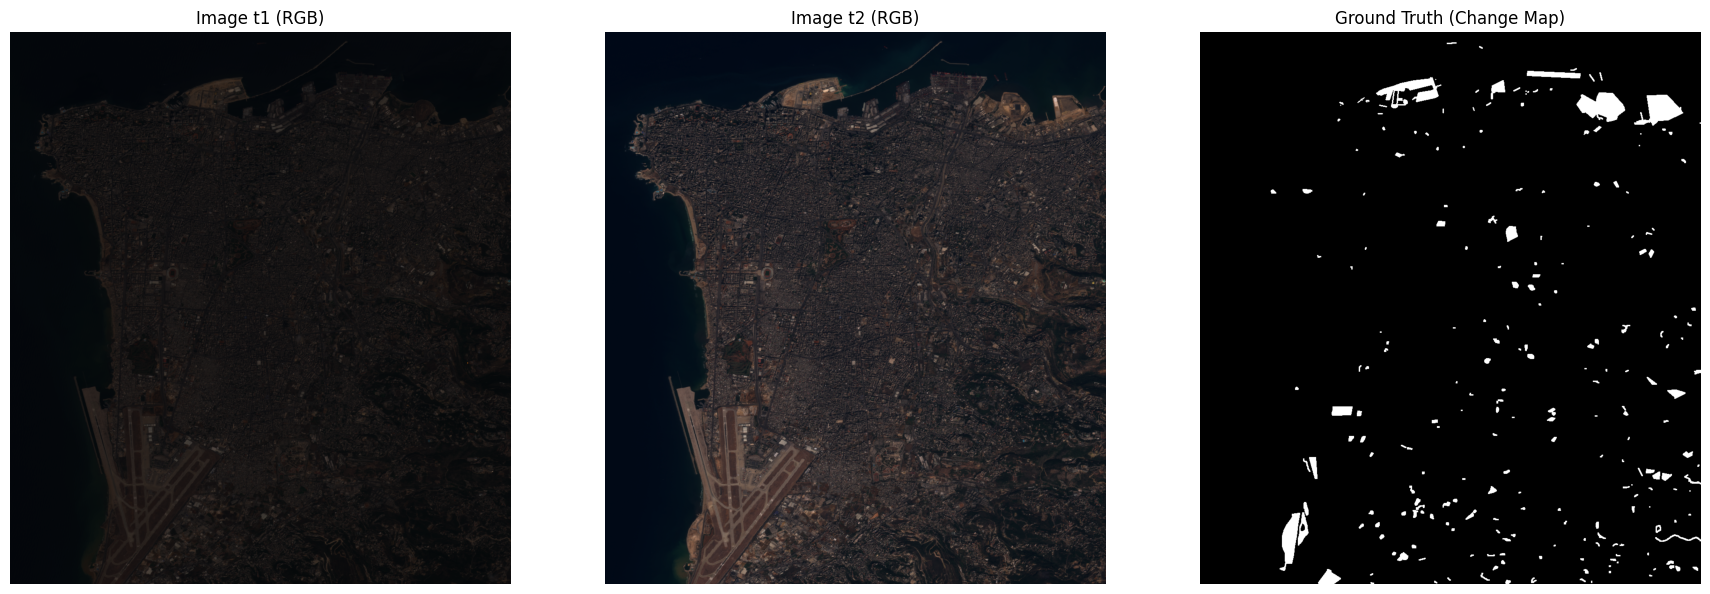

In [10]:
def visualize_data(img1: np.ndarray, img2: np.ndarray, label: np.ndarray):
    """Affiche les images RGB et le ground truth."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)

    axes[0].imshow(to_rgb(img1))
    axes[0].set_title('Image t1 (RGB)')
    axes[0].axis('off')

    axes[1].imshow(to_rgb(img2))
    axes[1].set_title('Image t2 (RGB)')
    axes[1].axis('off')

    axes[2].imshow(label * 255, cmap='gray')
    axes[2].set_title('Ground Truth (Change Map)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_data(img1, img2, ground_truth)

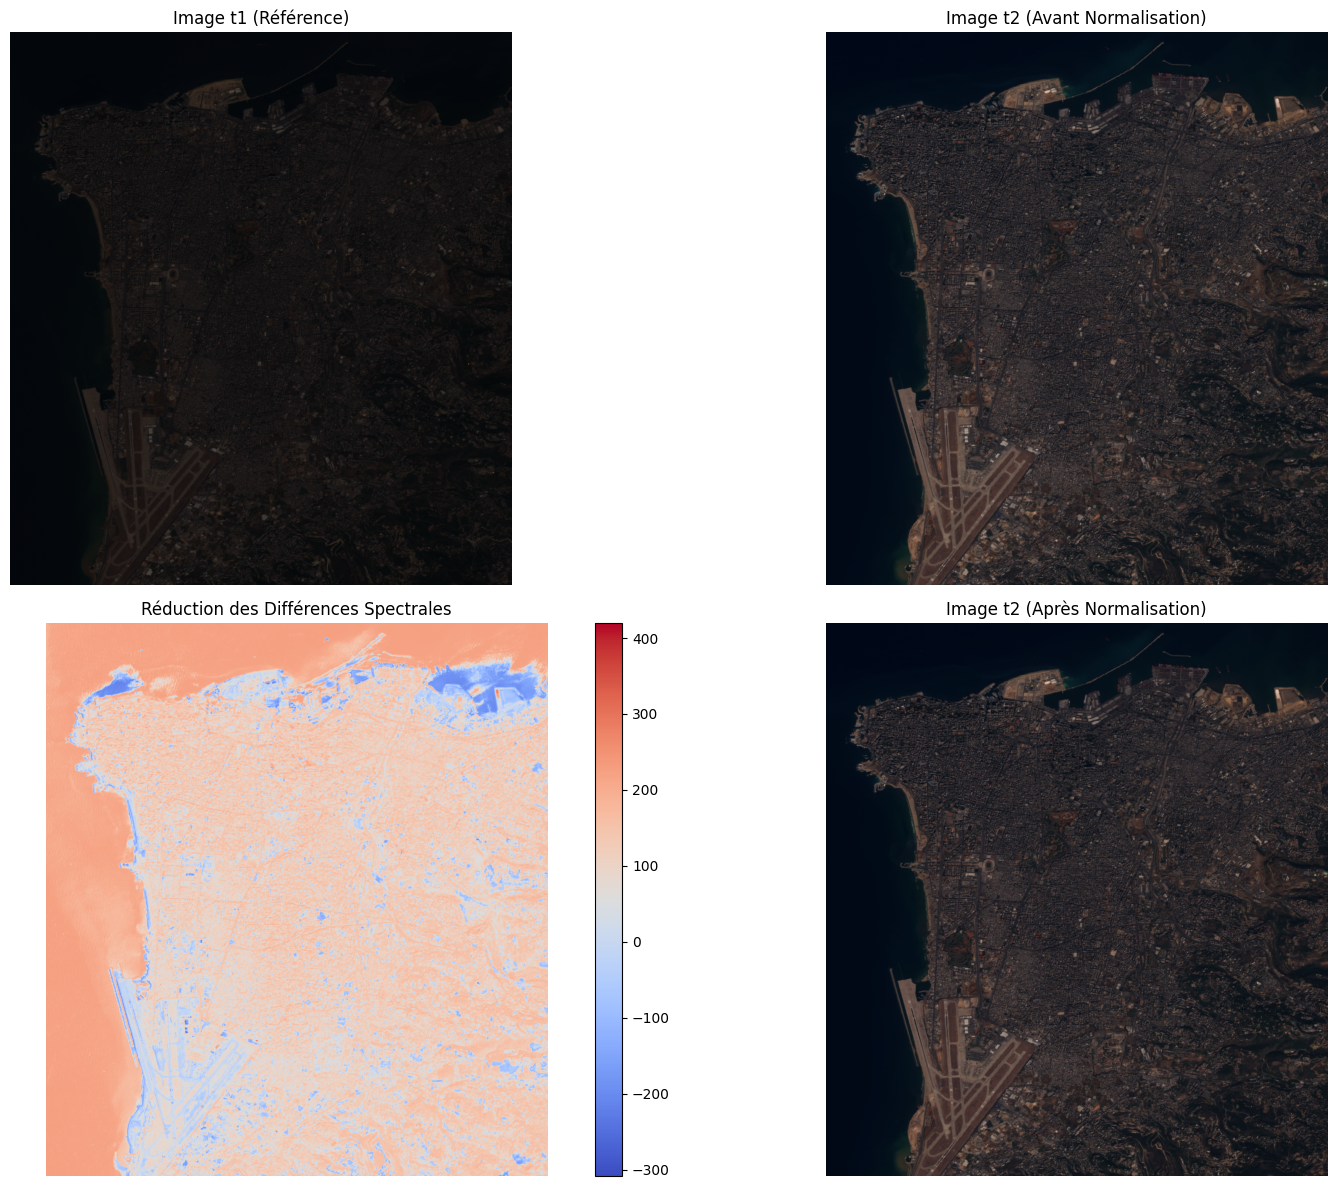

In [11]:
def visualize_radiometric_normalization(t1: np.ndarray, t2: np.ndarray):
    """
    Visualise l'effet de la normalisation radiométrique relative (RRN).

    Args:
        t1: Image de référence (H, W, B).
        t2: Image à normaliser (H, W, B).
    """
    # Appliquer la normalisation radiométrique
    t2_norm = radiometric_normalization(t1, t2)

    # Calculer les différences spectrales avant et après normalisation
    diff_before = np.linalg.norm(t2 - t1, axis=2)
    diff_after = np.linalg.norm(t2_norm - t1, axis=2)

    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)

    # Afficher t1 (référence)
    axes[0, 0].imshow(to_rgb(t1))
    axes[0, 0].set_title('Image t1 (Référence)')
    axes[0, 0].axis('off')

    # Afficher t2 avant normalisation
    axes[0, 1].imshow(to_rgb(t2))
    axes[0, 1].set_title('Image t2 (Avant Normalisation)')
    axes[0, 1].axis('off')

    # Afficher la différence entre les différences spectrales
    im3 = axes[1, 0].imshow(diff_before - diff_after, cmap='coolwarm')
    axes[1, 0].set_title('Réduction des Différences Spectrales')
    axes[1, 0].axis('off')
    fig.colorbar(im3, ax=axes[1, 0])

    # Afficher t2 normalisée
    axes[1, 1].imshow(to_rgb(t2_norm))
    axes[1, 1].set_title('Image t2 (Après Normalisation)')
    axes[1, 1].axis('off')


    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
visualize_radiometric_normalization(img1, img2)

## Algorithme 1 : PCA-Kmeans

In [13]:
class PCAKmeans:
    """PCA pour débruitage + K-means pour clustering binaire."""

    def __init__(self, n_components: int = 3):
        """
        Args:
            n_components: Nombre de composantes principales à conserver
        """
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)

    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Calcule la carte de changement binaire en utilisant PCA + K-means."""
        # Normalisation
        img2 = radiometric_normalization(img1, img2)
        img1 = normalize_image(img1)
        img2 = normalize_image(img2)

        # Image différence
        diff = img2 - img1
        H, W, C = diff.shape
        diff_flat = diff.reshape(-1, C)

        # PCA
        diff_pca = self.pca.fit_transform(diff_flat)

        # K-means clustering (k=2)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(diff_pca)

        # Identifier le cluster "changement" : celui avec variance max ou distance au centre max
        cluster_0_var = diff_pca[labels == 0].var()
        cluster_1_var = diff_pca[labels == 1].var()
        change_label = 0 if cluster_0_var > cluster_1_var else 1
        change_map = (labels == change_label).reshape(H, W).astype(np.uint8)

        # Post-traitement pour éliminer le bruit
        structElement = morphology.disk(1)
        change_map = morphology.binary_opening(change_map, structElement)
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=25)

        return change_map

## Algorithme 2 : CVA (Change Vector Analysis)

In [12]:
class CVA:
    """Change Vector Analysis"""

    def __init__(self):
        self.threshold = None
        self.magnitude = None

    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Calcule la carte de changement binaire en utilisant la méthode CVA."""
        # On n'utilise que les 4 premières bandes (résolution 10m)
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]

        # Normalisation
        img2 = radiometric_normalization(img1, img2)
        img1 = normalize_image(img1)
        img2 = normalize_image(img2)

        # Calcul de la magnitude du vecteur de changement
        diff = img2 - img1
        self.magnitude = np.sqrt(np.sum(diff**2, axis=2))

        # Filtrage médian pour réduire le bruit
        self.magnitude = median_filter(self.magnitude, size=5)

        # Seuillage et binarisation
        #self.threshold = threshold_otsu(self.magnitude)
        #self.threshold = np.percentile(self.magnitude, 90)
        self.threshold = threshold_triangle(self.magnitude)
        change_map = (self.magnitude > self.threshold).astype(np.uint8)

        # Post-traitement pour éliminer le bruit
        change_map = binary_opening(change_map, structure=np.ones((3,3))).astype(np.uint8)
        change_map = binary_closing(change_map, structure=np.ones((3,3))).astype(np.uint8)
        change_map = filter_by_area(change_map, min_area_pixels=25)

        return change_map

## Algorithme 3 : IR-MAD

In [14]:
class IRMAD:
    """Iteratively Reweighted Multivariate Alteration Detection (IR-MAD)"""

    def __init__(self, niter: int = 10):
        """
        Args:
            niter: Nombre d'itérations IR-MAD
        """
        self.niter = niter
        self.chi2_dist = None
        self.mad_variates = None
        self.pvs = None

    @staticmethod
    def np_weight_stats(x: np.ndarray, ws: np.ndarray = None) -> tuple:
        """
        Calcule la moyenne et la covariance pondérées.

        Args:
            x: Matrice de données (N, D)
            ws: Vecteur de poids (N,)

        Returns:
            (wsigma, wmean): Covariance pondérée et moyenne pondérée
        """
        if ws is None or not np.any(ws):
            ws = np.ones(x.shape[0])
        mean = np.ma.average(x, axis=0, weights=ws)
        wmean = np.expand_dims(mean.data, axis=1)
        wsigma = np.cov(x, rowvar=False, aweights=ws)
        return wsigma, wmean

    def apply_maf(self, mads: np.ndarray, width: int, height: int) -> np.ndarray:
        """
        Applique la transformation MAF (Maximum Autocorrelation Factor) aux variates MAD.

        Args:
            mads: Variates MAD (N_pixels, N_bands)
            width: Largeur de l'image
            height: Hauteur de l'image

        Returns:
            Variates transformées MAF (N_pixels, N_bands), triées par autocorrélation décroissante.
        """
        N_bands = mads.shape[1]
        img = mads.reshape(height, width, N_bands) # (H, W, C)

        # Calcul des différences spatiales
        diff_h = img[:, :-1, :] - img[:, 1:, :]
        diff_v = img[:-1, :, :] - img[1:, :, :]
        data_diff = np.vstack((
            diff_h.reshape(-1, N_bands),
            diff_v.reshape(-1, N_bands)
        ))

        # Calcul des matrices de covariance
        sigma_delta = np.cov(data_diff, rowvar=False)
        sigma_mad = np.cov(mads, rowvar=False)

        # Résolution du problème généralisé
        evals, evecs = linalg.eigh(sigma_delta, sigma_mad)

        return mads @ evecs

    def detect(self, img1: np.ndarray, img2: np.ndarray, threshold_percentage: float = 96, use_maf: bool = False) -> np.ndarray:
        """
        Calcul de la carte de changement binaire en utilisant la méthode IR-MAD.

        Args:
            img1: Image t1 (H, W, C)
            img2: Image t2 (H, W, C)
            threshold_percentage: Pourcentage pour le seuil de changement (ex: 96 pour les 4% les plus changeants)
            use_maf: Applique la transformation MAF aux variates MAD pour améliorer la détection

        Returns:
            Carte binaire de changement (H, W)
        """
        # On n'utilise que les 4 premières bandes (résolution 10m)
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]

        H, W, C = img1.shape
        N = C
        m = H * W

        im1r = img1.reshape(m, N)
        im2r = img2.reshape(m, N)
        x = np.concatenate((im1r, im2r), axis=1)

        # Initialisation des poids uniforme
        pvs = np.ones(m, dtype=np.float32)

        for itr in tqdm(range(self.niter), desc="IR-MAD iterations"):
            # Calcul des statistiques pondérées
            sigma, mean = self.np_weight_stats(x, pvs)

            ms1 = mean[:N].T  # Moyenne image 1
            ms2 = mean[N:].T  # Moyenne image 2

            # Matrices de covariance par blocs
            reg = 1 * np.eye(N) # Régularisation
            sigma11 = sigma[:N, :N] + reg
            sigma12 = sigma[:N, N:]
            sigma21 = sigma[N:, :N]
            sigma22 = sigma[N:, N:] + reg

            # Résolution des problèmes aux valeurs propres généralisés
            A1 = sigma12 @ np.linalg.solve(sigma22, sigma12.T)
            A2 = sigma12.T @ np.linalg.solve(sigma11, sigma12)
            lamda1, eigvec1 = linalg.eigh(A1, sigma11)
            lamda2, eigvec2 = linalg.eigh(A2, sigma22)

            # Tri décroissant par valeur propre
            idx1 = np.argsort(lamda1)[::-1]
            lamda1 = lamda1[idx1]
            eigvec1 = eigvec1[:, idx1]
            idx2 = np.argsort(lamda2)[::-1]
            lamda2 = lamda2[idx2]
            eigvec2 = eigvec2[:, idx2]

            # Corrélations canoniques
            rho2 = lamda1  # lamda1 == lamda2 en théorie
            rho = np.sqrt(np.clip(rho2, 0, 1))  # Sécurité numérique

            # Assurer corrélation positive entre paires de variates canoniques
            diag = np.diag(eigvec1.T @ sigma12 @ eigvec2)
            signs = np.diag(diag / (np.abs(diag) + 1e-10))
            eigvec2 = eigvec2 @ signs

            # Calcul des variates MAD
            sig2s = 2 * (1 - rho)
            sig2s = np.tile(sig2s, (m, 1))  # (m, N)
            ms1_tile = np.tile(ms1[0], (m, 1))  # (m, N)
            ms2_tile = np.tile(ms2[0], (m, 1))  # (m, N)

            # Variates canoniques
            cv1 = (im1r - ms1_tile) @ eigvec1
            cv2 = (im2r - ms2_tile) @ eigvec2
            mads = cv1 - cv2

            # Distance Chi-carré
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)

            # Mise à jour des poids (p-values)
            pvs = 1 - chi2(N).cdf(chisqr)
            pvs = pvs.squeeze()
            pvs = np.clip(pvs, 1e-10, 1.0)

        if use_maf:
            mads = self.apply_maf(mads, W, H)
            mads = mads[:, :4]
            chisqr = np.sum(np.square(mads), axis=1)
        else:
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)

        self.mad_variates = mads
        self.chi2_dist = chisqr.reshape(H, W)
        self.pvs = pvs.reshape(H, W)

        # Lissage morphologique sur chi2 pour réduire le bruit avant seuillage
        structElement = morphology.disk(1)
        chi2_smooth = morphology.opening(self.chi2_dist, structElement)

        # Seuillage
        threshold = np.percentile(chi2_smooth, threshold_percentage)
        change_map = (chi2_smooth > threshold).astype(np.uint8)

        # Post-traitement binaire léger pour éliminer les petits objets
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=75)

        return change_map

## Algorithme 4 : SiROC

In [15]:
class SiROC:
    """
    Notre implémentation de SiROC (Spectral Regression for Change Detection) avec régression robuste globale 
    et accumulation de différences spectrales sur un ensemble de polynômes d'ordre faible.
    """

    def __init__(self, s=1, n_max=4, min_area=25):
        """
        Args:
            s: pas pour les degrés de polynômes
            n_max: degré maximum des polynômes à tester
            min_area: aire minimale en pixels
        """
        self.s = s
        self.n_max = n_max
        self.min_area = min_area
        self.uncertainty_map = None

    @staticmethod
    def _normalize(img):
        """Normalisation Z-score par bande."""
        img = img.astype(np.float32)
        for b in range(img.shape[2]):
            mu = img[:, :, b].mean()
            std = img[:, :, b].std() + 1e-6
            img[:, :, b] = (img[:, :, b] - mu) / std
        return img

    def _apply_hsr(self, I_t, I_t1, degree):
        """Régression robuste "sibling" globale pour un degré de polynôme donné."""
        H, W, B = I_t.shape
        I_hat = np.zeros_like(I_t)

        for b in range(B):
            x = I_t[:, :, b].reshape(-1, 1)
            y = I_t1[:, :, b].reshape(-1)

            poly = PolynomialFeatures(degree=degree, include_bias=True)
            X_poly = poly.fit_transform(x)

            reg = HuberRegressor(
                epsilon=1.35,
                alpha=0.0,
                max_iter=200
            )
            reg.fit(X_poly, y)

            y_hat = reg.predict(X_poly)
            I_hat[:, :, b] = y_hat.reshape(H, W)

        return I_hat

    def detect(self, img1, img2):
        """Calcule la carte de changement binaire en utilisant notre implémentation de SiROC."""
        # Normalisation
        img1 = self._normalize(img1)
        img2 = self._normalize(img2)

        H, W, _ = img1.shape
        self.uncertainty_map = np.zeros((H, W), dtype=np.float32)

        # Ensemble de polynômes d'ordre faible avec un pas de 1
        for degree in range(1, self.n_max, self.s):
            I_hat = self._apply_hsr(img1, img2, degree)
            diff = np.sum(np.abs(I_hat - img2), axis=2)
            self.uncertainty_map += diff

        # Seuillage d'Otsu et binarisation
        th = threshold_otsu(self.uncertainty_map)
        change_map = (self.uncertainty_map > th)

        # Post-traitement pour éliminer le bruit
        se = disk(1)
        change_map = opening(change_map, se)
        change_map = closing(change_map, se)
        change_map = remove_small_objects(change_map, self.min_area)

        return change_map.astype(np.uint8)


In [16]:
class SiROCFast:
    """Version optimisée de SiROC avec régression locale utilisant des convolutions pour accélérer le calcul des sommes de voisinage."""

    def __init__(
        self,
        max_neighborhood: int = 200,
        splits: int = 27,
        ensemble: bool = True,
        morph_operations: bool = True,
        mp_start: int = 5,
        mp_stop: int = 6,
        mp_step: int = 1,
        manual_otsu_factor: float = 1.0
    ):
        """
        Args:
            max_neighborhood: Taille maximale du voisinage pour la régression locale 
            splits: Nombre de splits pour l'ensemble de voisinages 
            ensemble: Utiliser un ensemble ou un seul voisinage
            morph_operations: Filtre morphologique pour réduire le bruit 
            mp_start, mp_stop, mp_step: Paramètres pour le split des voisinages 
            manual_otsu_factor: Facteur multiplicatif pour ajuster le seuil d'Otsu
        """
        self.max_neighborhood = max_neighborhood
        self.splits = splits
        self.ensemble = ensemble
        self.morph_operations = morph_operations

        self.mp_start = mp_start
        self.mp_stop = mp_stop
        self.mp_step = mp_step

        self.manual_otsu_factor = manual_otsu_factor
        self.voting_threshold, self.auto_otsu_factor = self._call_voting_parameters()
        self.otsu_factor = self.manual_otsu_factor if self.manual_otsu_factor else self.auto_otsu_factor

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _call_voting_parameters(self):
        """Initialise les paramètres de vote pour l'ensemble de voisinages."""
        if self.morph_operations:
            return 0.5, 1.0
        return 0.35, 0.75 if self.ensemble else 0.65

    @staticmethod
    def normalize_input(img):
        """Normalisation Z-score par bande."""
        return (img - img.mean()) / (img.std() + 1e-8)

    def _split_neighborhood_uniform(self, neighborhood, splits, excluded):
        """Divise uniformément le voisinage en plusieurs splits pour l'ensemble."""
        splitted = []
        step = max(1, (neighborhood - excluded) // splits)
        for i in range(1, splits + 1):
            local_n = step * i + excluded
            ex = step * (i - 1) + excluded
            splitted.append((local_n, ex))
        return splitted

    def _separable_box_sum(self, img_tensor, radius):
        """
        Calcule la somme des pixels dans un voisinage carré de taille (2*radius+1) x (2*radius+1) 
        de manière efficace en utilisant des convolutions séparables.
        Complexité : O(radius) au lieu de O(radius^2) pour une somme naïve.
        """
        if radius <= 0:
            return img_tensor

        kernel_size = 2 * radius + 1
        channels = img_tensor.shape[1]

        # Passe verticale (Somme des voisins en colonne)
        k_y = torch.ones((channels, 1, kernel_size, 1), device=self.device)
        pad_y = F.pad(img_tensor, (0, 0, radius, radius), mode='replicate')
        temp = F.conv2d(pad_y, k_y, groups=channels)

        # Passe horizontale (Somme des voisins en ligne)
        k_x = torch.ones((channels, 1, 1, kernel_size), device=self.device)
        pad_x = F.pad(temp, (radius, radius, 0, 0), mode='replicate')
        return F.conv2d(pad_x, k_x, groups=channels)

    def _obtain_change_map(self, pre, post, neighborhood, excluded=0):
        """Calcule la carte de changement pour un voisinage donné en utilisant une régression locale rapide."""
        pre_response = pre ** 2
        post_response = pre * post

        # Outer sum pour les deux images
        pre_sum_big = self._separable_box_sum(pre_response, neighborhood)
        post_sum_big = self._separable_box_sum(post_response, neighborhood)

        # Soustraction des sommes plus petites si on exclut une partie du voisinage
        if excluded > 0:
            pre_sum_small = self._separable_box_sum(pre_response, excluded)
            post_sum_small = self._separable_box_sum(post_response, excluded)

            pre_sum = pre_sum_big - pre_sum_small
            post_sum = post_sum_big - post_sum_small
        else:
            pre_sum = pre_sum_big
            post_sum = post_sum_big

        epsilon = 1e-6
        ratio_map = post_sum / (pre_sum + epsilon)
        post_pred = pre * ratio_map
        return torch.abs(post_pred - post), ratio_map

    def detect(self, img1: np.ndarray, img2: np.ndarray, debug=False) -> np.ndarray:
        """Calcule la carte de changement binaire en utilisant notre implémentation optimisée de SiROC."""
        img1_norm = self.normalize_input(img1)
        img2_norm = self.normalize_input(img2)

        # Déplacement sur le GPU
        t1 = torch.from_numpy(img1_norm).permute(2, 0, 1).float().unsqueeze(0).to(self.device)
        t2 = torch.from_numpy(img2_norm).permute(2, 0, 1).float().unsqueeze(0).to(self.device)

        if self.ensemble:
            neighborhoods = self._split_neighborhood_uniform(self.max_neighborhood, self.splits, 0)
            raw_maps = []
            binary_maps = []
            debug_ratio = None

            for i, (n, ex) in enumerate(neighborhoods):
                c_map_tensor, ratio = self._obtain_change_map(t1, t2, n, ex) # sur le GPU
                c_map = c_map_tensor.squeeze(0).mean(dim=0).cpu().numpy()

                # Pour le debug, on sauvegarde la carte de ratio du split du milieu
                if debug and i == len(neighborhoods)//2:
                    debug_ratio = ratio.squeeze(0).mean(dim=0).cpu().numpy()
                
                c_map = np.nan_to_num(c_map)
                raw_maps.append(c_map)

                # Normalization & Seuillage d'Otsu
                mi, ma = c_map.min(), c_map.max()
                c_map_norm = (c_map - mi) / (ma - mi) if ma > mi else np.zeros_like(c_map)
                val_for_otsu = (c_map_norm * 255).astype(np.uint8)
                t_otsu = cv2.threshold(val_for_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
                binary = (c_map_norm > (t_otsu * self.otsu_factor / 255)).astype(np.float32)

                # Filtrage morphologique pour réduire le bruit
                if self.morph_operations:
                    morph_profile = np.zeros_like(binary)
                    count = 0
                    for kernel_size in range(self.mp_start, self.mp_stop, self.mp_step):
                        kernel = np.ones((kernel_size, kernel_size), np.uint8)
                        closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
                        opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
                        morph_profile += opened
                        count += 1
                    if count > 0:
                        binary = morph_profile / count

                binary_maps.append(binary)

            vote_map = np.mean(binary_maps, axis=0)
            final_map = (vote_map >= self.voting_threshold).astype(np.uint8)

            if debug:
                # Ajoute une carte de vote pour visualiser l'impact de l'ensemble
                return final_map, np.mean(raw_maps, axis=0), debug_ratio, vote_map

        return final_map

## Algorithme 5 : IR-MAD avec Graph Cuts (régularisation spatiale)

In [17]:
def graph_cut_mrf_regularization(chi2_map: np.ndarray, threshold: float, beta: float = 1.0) -> np.ndarray:
    """
    Régularisation par Graph Cuts basée sur l'énergie de Markov.

    Args:
        chi2_map: Carte de distance Chi² IR-MAD [H, W]
        threshold: Seuil de séparation changement / non-changement
        beta: Poids du terme de régularisation spatiale 

    Returns:
        Carte binaire de changement (1 = changement, 0 = non-changement)

    Principe:
        Minimise l'énergie E = E_data + E_smooth où:
        - E_data: pénalise les pixels mal classés selon leur valeur chi²
        - E_smooth: pénalise les discontinuités spatiales (favorise l'homogénéité)
    """
    # Paramètres du modèle d'énergie
    E_max = 10.0 # Énergie maximale pour éviter divergence
    alpha = 0.0000001 # Contrôle la largeur de la zone d'incertitude

    # Seuils adaptatifs autour du threshold
    mu_s = threshold + (1.0 / alpha) ** 0.5  # centre de la classe changement
    mu_t = threshold - (1.0 / alpha) ** 0.5  # centre de la classe non-changement

    # Terme de données
    E_source = alpha * (mu_s - chi2_map) ** 2 # Énergie pour label "changement" (Source)
    E_source = np.clip(E_source, 0, E_max)
    E_source[chi2_map > mu_s] = 0 
    E_sink = alpha * (mu_t - chi2_map) ** 2 # Énergie pour label "non-changement" (Sink)
    E_sink = np.clip(E_sink, 0, E_max)
    E_sink[chi2_map < mu_t] = 0 

    # Construction du graphe
    g = maxflow.Graph[float]()
    nodeids = g.add_grid_nodes(chi2_map.shape)

    # T-links: connexions terminales (Source/Sink)
    g.add_grid_tedges(nodeids, E_sink, E_source)

    # N-links: connexions entre voisins (4-connecté)
    g.add_grid_edges(nodeids, beta) # beta contrôle la force de la régularisation spatiale

    # Optimisation par Max-Flow / Min-Cut
    g.maxflow()

    # Récupérer la segmentation
    segments = g.get_grid_segments(nodeids)

    # Inverser: 1 = changement, 0 = non-changement
    change_map = np.logical_not(segments).astype(np.uint8)

    # Filtrage des petits objets
    change_map = filter_by_area(change_map, min_area_pixels=100, max_area_pixels=50000)

    return change_map

Test avec différents paramètres de beta:



IR-MAD iterations: 100%|██████████| 10/10 [00:06<00:00,  1.54it/s]


Beta=0.1: 27292 pixels détectés comme changement (2.2%)
 F1=0.5299, Precision=0.5943, Recall=0.4782

Beta=1.0: 26403 pixels détectés comme changement (2.1%)
 F1=0.5493, Precision=0.6275, Recall=0.4885

Beta=5.0: 28948 pixels détectés comme changement (2.3%)
 F1=0.5691, Precision=0.6180, Recall=0.5274

Beta=10.0: 22660 pixels détectés comme changement (1.8%)
 F1=0.5924, Precision=0.7395, Recall=0.4940



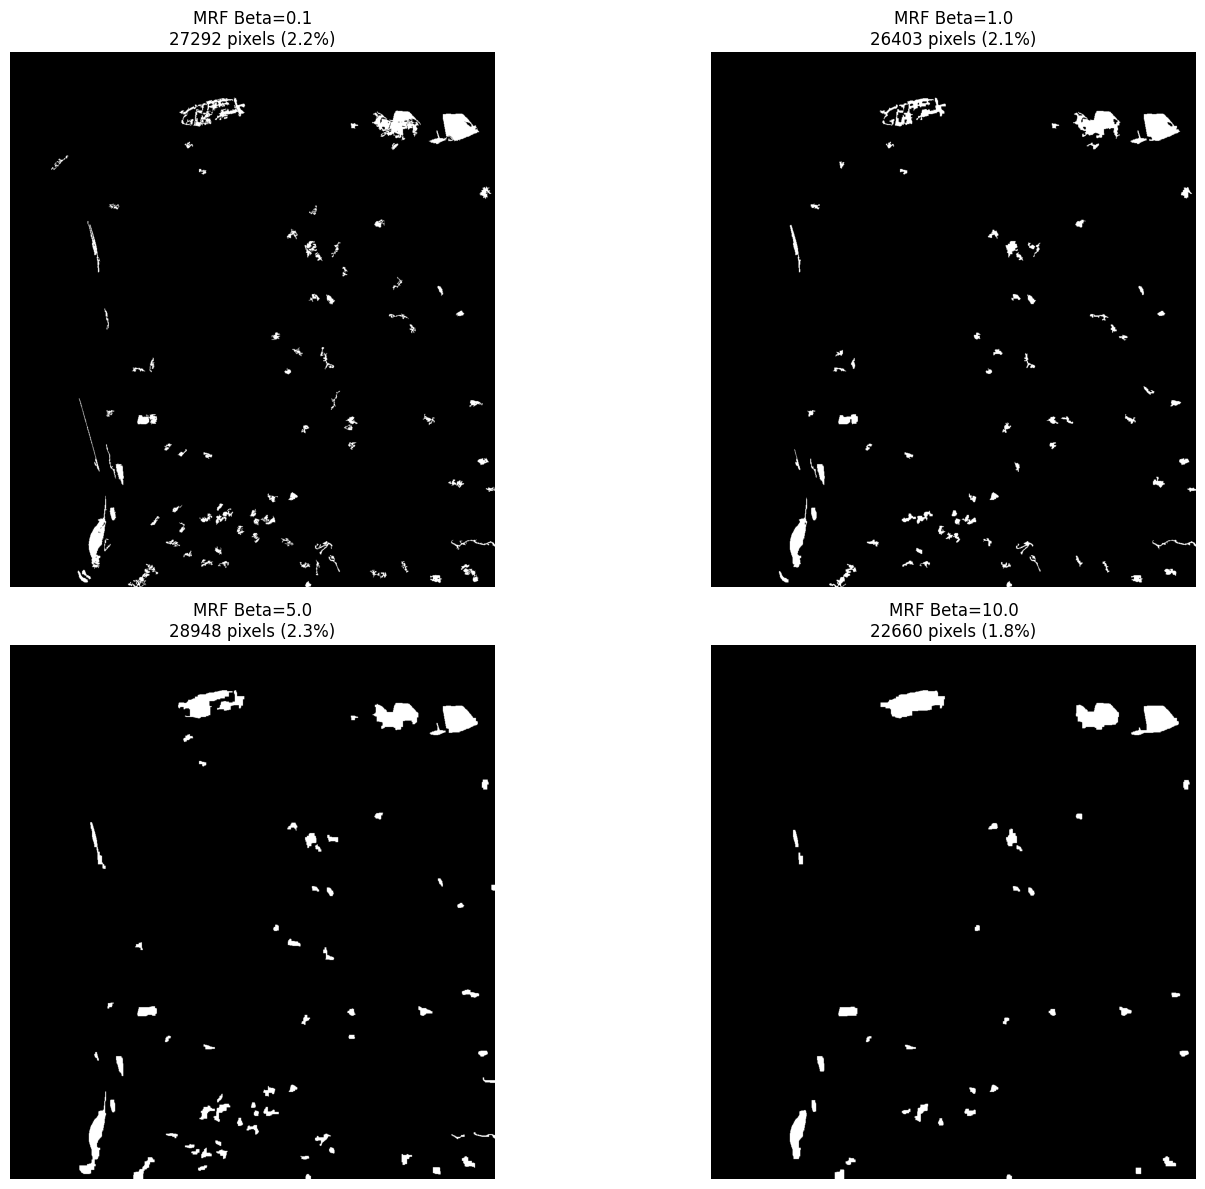

In [18]:
print("Test avec différents paramètres de beta:\n")

irmad = IRMAD(niter=10)
_ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
threshold = np.percentile(irmad.chi2_dist, 90)

# Tester différentes valeurs de beta
beta_values = [0.1, 1.0, 5.0, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, beta in enumerate(beta_values):
    mrf_result = graph_cut_mrf_regularization(irmad.chi2_dist, threshold, beta)
    n_changes = mrf_result.sum()
    pct_changes = 100 * n_changes / mrf_result.size

    # Calcul des métriques
    f1 = f1_score(ground_truth.flatten(), mrf_result.flatten())
    precision = precision_score(ground_truth.flatten(), mrf_result.flatten())
    recall = recall_score(ground_truth.flatten(), mrf_result.flatten())
    print(f"Beta={beta}: {n_changes} pixels détectés comme changement ({pct_changes:.1f}%)")
    print(f" F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}\n")

    # Visualisation
    axes[idx].imshow(mrf_result, cmap='gray')
    axes[idx].set_title(f'MRF Beta={beta}\n{n_changes} pixels ({pct_changes:.1f}%)')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Évaluation des Méthodes

In [19]:
class ChangeDetectionEvaluator:
    """Évaluateur pour les méthodes de détection de changement."""

    @staticmethod
    def compute_metrics(pred: np.ndarray, gt: np.ndarray) -> Dict[str, float]:
        """Calcule les métriques de performance."""
        pred_flat = pred.flatten()
        gt_flat = gt.flatten()

        metrics = {
            'Precision': precision_score(gt_flat, pred_flat, zero_division=0),
            'Recall': recall_score(gt_flat, pred_flat, zero_division=0),
            'F1-Score': f1_score(gt_flat, pred_flat, zero_division=0),
        }

        # Matrice de confusion
        tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat).ravel()
        metrics['TN'] = tn
        metrics['FP'] = fp
        metrics['FN'] = fn
        metrics['TP'] = tp

        return metrics

    @staticmethod
    def print_metrics(method_name: str, metrics: Dict[str, float]):
        """Affiche les métriques."""
        print(f"\n{'='*50}")
        print(f"Méthode: {method_name}")
        print(f"{'='*50}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"TP: {metrics['TP']}, FP: {metrics['FP']}, FN: {metrics['FN']}, TN: {metrics['TN']}")

In [49]:
def visualize_change_maps(ground_truth: np.ndarray, **change_maps):
    """
    Visualise les cartes de changement binaires produites.

    Args:
        ground_truth: Carte de changement de référence (binaire).
        change_maps: Dictionnaire contenant les cartes de changement binaires (nom -> carte).
    """
    n_rows, n_cols = 2, 4
    fig = plt.figure(figsize=(24, 12))
    gs = gridspec.GridSpec(n_rows, n_cols, width_ratios=[1, 1, 1, 1])

    # Ground Truth occupe les deux lignes de la première colonne (centré verticalement)
    ax_gt = fig.add_subplot(gs[:, 0])
    ax_gt.imshow(ground_truth * 255, cmap='gray')
    ax_gt.set_title('Ground Truth', fontsize=22)
    ax_gt.axis('off')

    # Les autres cartes
    method_axes = []
    for i in range(1, n_cols):
        for j in range(n_rows):
            method_axes.append(fig.add_subplot(gs[j, i]))

    for ax, (method_name, change_map) in zip(method_axes, change_maps.items()):
        ax.imshow(change_map * 255, cmap='gray')
        ax.set_title(method_name, fontsize=22)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Exemple de détection sur une image

In [22]:
# Calcul des cartes de changement pour les différentes méthodes
cva = CVA() 
cva_result = cva.detect(img1, img2) 

pca_kmeans = PCAKmeans(n_components=3) 
pca_kmeans_result = pca_kmeans.detect(img1, img2) 

irmad = IRMAD(niter=10) 
irmad_result = irmad.detect(img1, img2, threshold_percentage=96, use_maf=False) 

irmad = IRMAD(niter=10)
_ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
irmad_mrf_result = graph_cut_mrf_regularization(irmad.chi2_dist,threshold=np.percentile(irmad.chi2_dist, 90), beta=0.5)

siroc = SiROC(s=1, n_max=4, min_area=25) 
siroc_result = siroc.detect(img1, img2) 

siroc_fast = SiROCFast(max_neighborhood=200, splits=27, ensemble=True, morph_operations=True) 
siroc_fast_result = siroc_fast.detect(img1, img2)

IR-MAD iterations: 100%|██████████| 10/10 [00:06<00:00,  1.64it/s]


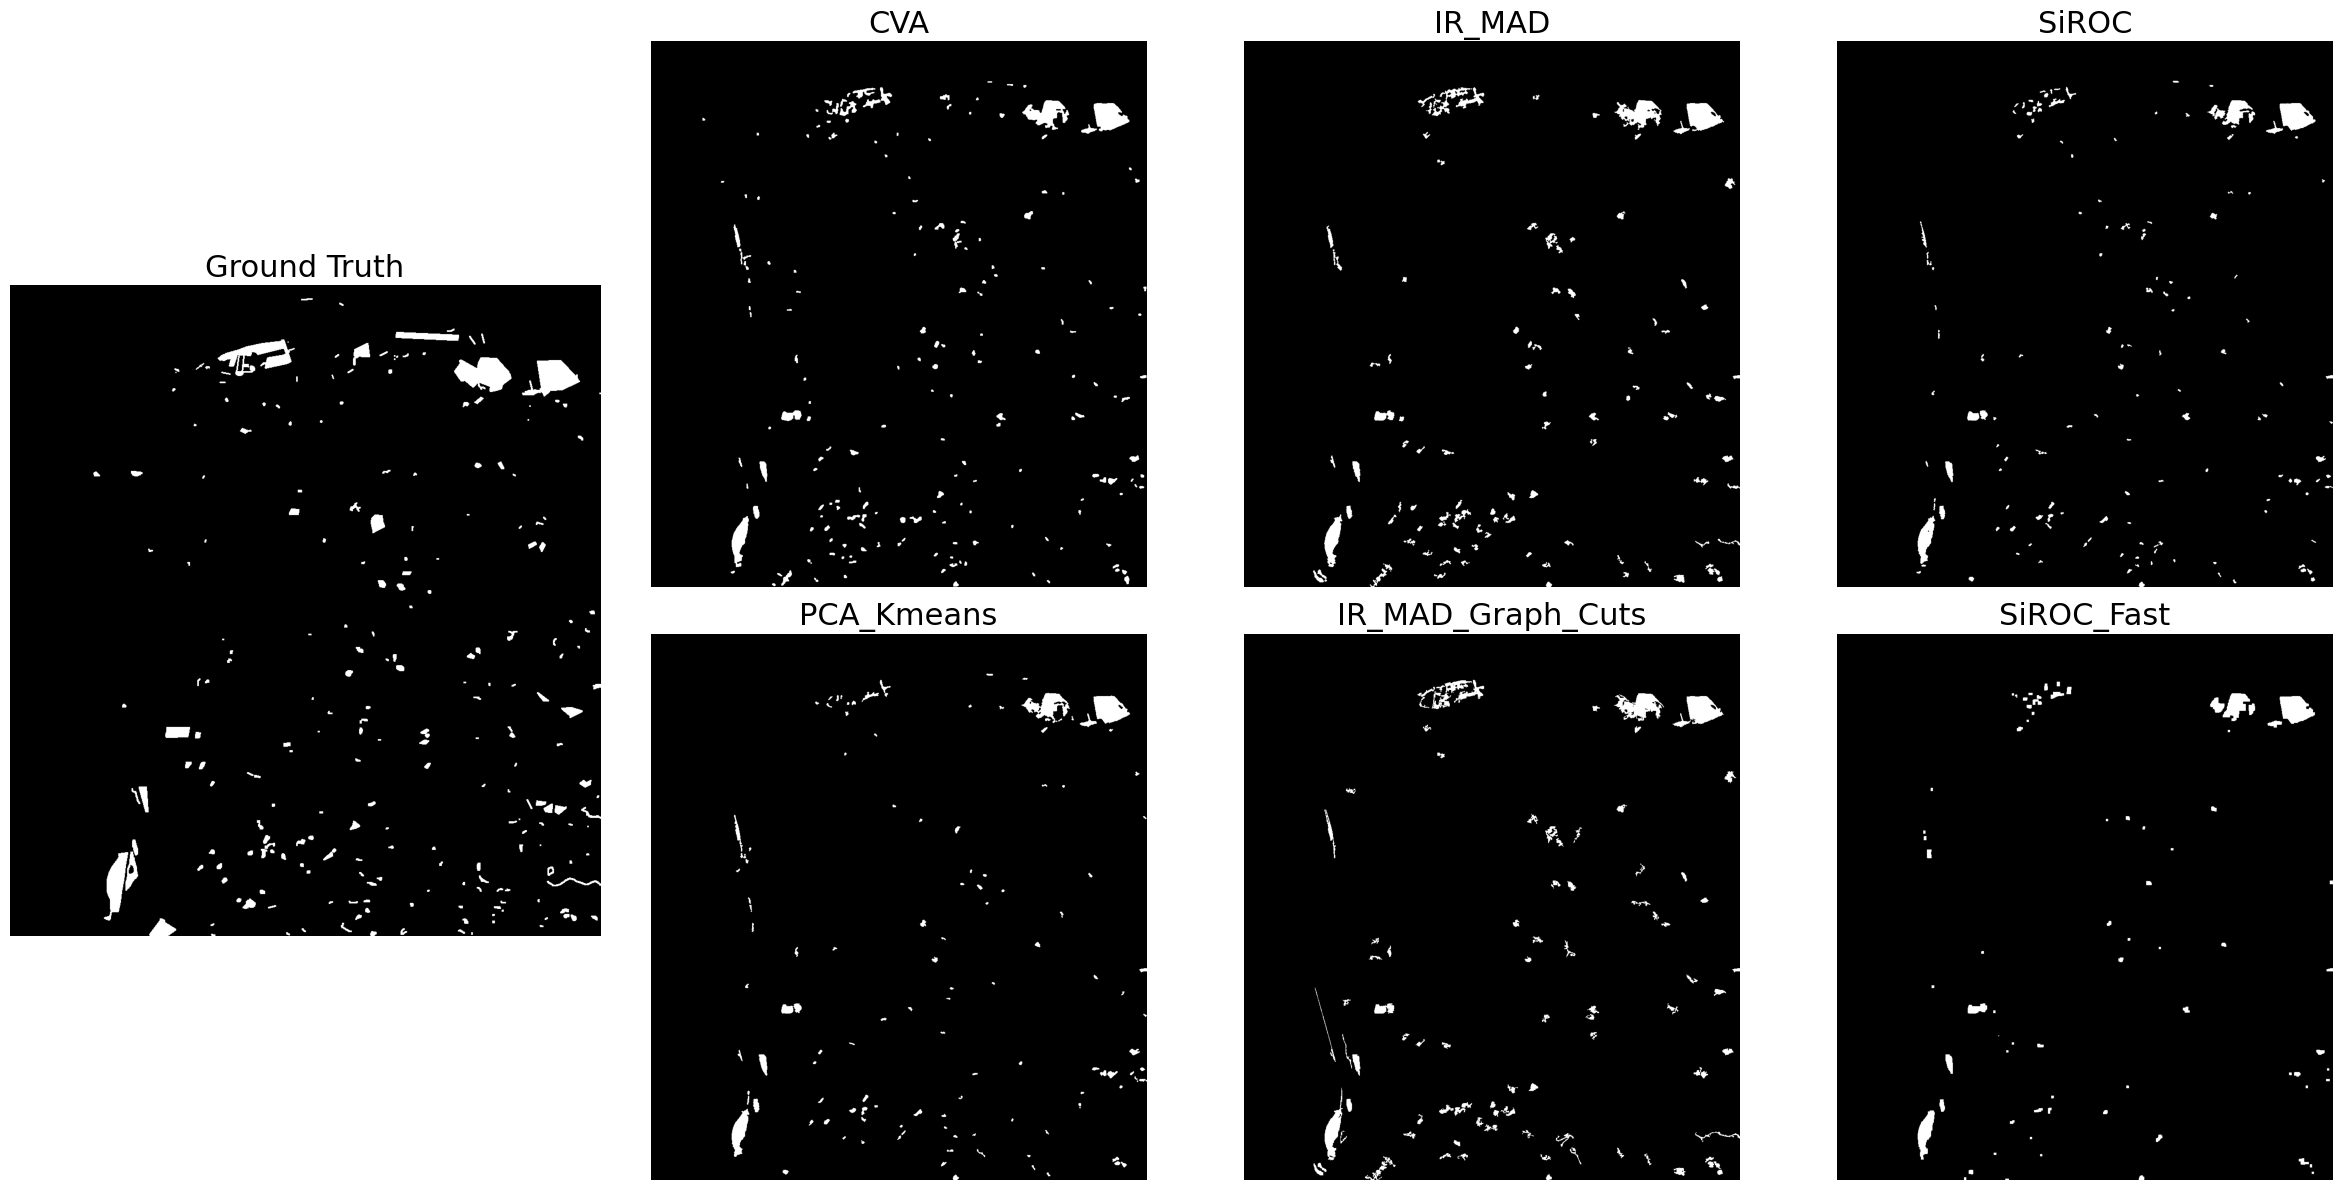

In [50]:
visualize_change_maps(
    ground_truth,
    CVA=cva_result,
    PCA_Kmeans=pca_kmeans_result,
    IR_MAD=irmad_result,
    IR_MAD_Graph_Cuts=irmad_mrf_result,
    SiROC=siroc_result,
    SiROC_Fast=siroc_fast_result
)

In [51]:
# Évaluation de toutes les méthodes sur l'image example
evaluator = ChangeDetectionEvaluator()

results = {
    'CVA': cva_result,
    'PCA-Kmeans': pca_kmeans_result,
    'IR-MAD': irmad_result,
    'IR-MAD + Graph Cuts': irmad_mrf_result,
    'SiROC': siroc_result,
    'SiROC Fast': siroc_fast_result
}

metrics_summary = {}
for method_name, prediction in results.items():
    metrics = evaluator.compute_metrics(prediction, ground_truth)
    metrics_summary[method_name] = metrics
    evaluator.print_metrics(method_name, metrics)


Méthode: CVA
F1-Score: 0.5782
Precision: 0.7104
Recall: 0.4876
TP: 16537, FP: 6742, FN: 17381, TN: 1221940

Méthode: PCA-Kmeans
F1-Score: 0.5315
Precision: 0.7945
Recall: 0.3994
TP: 13546, FP: 3504, FN: 20372, TN: 1225178

Méthode: IR-MAD
F1-Score: 0.5529
Precision: 0.6540
Recall: 0.4789
TP: 16245, FP: 8596, FN: 17673, TN: 1220086

Méthode: IR-MAD + Graph Cuts
F1-Score: 0.5482
Precision: 0.6283
Recall: 0.4862
TP: 16491, FP: 9758, FN: 17427, TN: 1218924

Méthode: SiROC
F1-Score: 0.5320
Precision: 0.8097
Recall: 0.3962
TP: 13437, FP: 3158, FN: 20481, TN: 1225524

Méthode: SiROC Fast
F1-Score: 0.5010
Precision: 0.8532
Recall: 0.3546
TP: 12027, FP: 2070, FN: 21891, TN: 1226612


## Optimisation sur l'ensemble d'entraînement

Nous exécutons toutes les méthodes sur les 14 locations d'entraînement pour comparer les approches et valider nos choix de paramètres. Les hyperparamètres (seuils, taille des filtres morphologiques, paramètres de régularisation, etc.) ont été ajustés en se basant uniquement sur les résultats sur l'ensemble d'entraînement.

In [55]:
def process_locations(base_path: str, locations: List[str], methods_to_run: List[str] = None, label: str = ""):
    """
    Traite une liste de locations et calcule les métriques.

    Args:
        base_path: Chemin vers le dataset OSCD
        locations: Liste des locations à traiter
        methods_to_run: Liste des méthodes à exécuter
        label: Label ("TRAIN", "TEST")
    """
    if methods_to_run is None:
        methods_to_run = ['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']

    print(f"{'='*70}")
    print(f" {label} — {len(locations)} locations")
    print(f"{'='*70}")
    print(f"Locations: {locations}")
    print(f"Méthodes: {methods_to_run}")

    # Stockage des résultats
    all_metrics = {method: [] for method in methods_to_run}
    evaluator = ChangeDetectionEvaluator()

    for idx, location in enumerate(locations):
        print(f"\n{'='*70}")
        print(f"[{idx+1}/{len(locations)}] Traitement de : {location} ({label})")
        print(f"{'='*70}")

        # Charger les données
        loader = OSCDDataLoader(base_path, location)
        img1, img2, ground_truth = loader.load_data()
        results_location = {}

        # CVA
        if 'CVA' in methods_to_run:
            print("CVA...")
            cva = CVA()
            results_location['CVA'] = cva.detect(img1, img2)

        # PCA-Kmeans
        if 'PCA-Kmeans' in methods_to_run:
            print("PCA-Kmeans...")
            pca_kmeans = PCAKmeans(n_components=2)
            results_location['PCA-Kmeans'] = pca_kmeans.detect(img1, img2)

        # IR-MAD
        if 'IR-MAD' in methods_to_run:
            print("IR-MAD...")
            irmad = IRMAD(niter=10)
            results_location['IR-MAD'] = irmad.detect(img1, img2, threshold_percentage=96, use_maf=True)

        # IR-MAD + Graph Cuts
        if 'IR-MAD+GC' in methods_to_run:
            print("IR-MAD + Graph Cuts...")
            irmad = IRMAD(niter=10)
            _ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
            results_location['IR-MAD+GC'] = graph_cut_mrf_regularization(
                irmad.chi2_dist,
                threshold=np.percentile(irmad.chi2_dist, 90),
                beta=0.5
            )

        # SiROC (notre implémentation)
        if 'SiROC' in methods_to_run:
            print("SiROC...") 
            siroc_ours = SiROC(
                s=1,
                n_max=4,
                min_area=25
            )
            results_location['SiROC'] = siroc_ours.detect(img1, img2)

        # SiROCFast (implémentation optimisée GPU)
        if 'SiROCFast' in methods_to_run:
            print("SiROC (optimisé)...")
            siroc = SiROCFast(
                ensemble=True,
                morph_operations=True,
                max_neighborhood=200,
                splits=27,
                manual_otsu_factor=1.0
            )
            results_location['SiROCFast'] = siroc.detect(img1, img2)
        
        # Calculer les métriques
        for method_name, prediction in results_location.items():
            metrics = evaluator.compute_metrics(prediction, ground_truth)
            all_metrics[method_name].append(metrics)

    return all_metrics, locations

In [53]:
def compute_aggregate_metrics(all_metrics: Dict[str, List[Dict]]) -> pd.DataFrame:
    """Calcule les statistiques agrégées sur toutes les images pour chaque méthode."""
    summary = {}

    for method_name, metrics_list in all_metrics.items():
        if len(metrics_list) == 0:
            continue

        f1_scores = [m['F1-Score'] for m in metrics_list]
        precisions = [m['Precision'] for m in metrics_list]
        recalls = [m['Recall'] for m in metrics_list]

        summary[method_name] = {
            'F1-Score (mean)': np.mean(f1_scores),
            'F1-Score (std)': np.std(f1_scores),
            'Precision (mean)': np.mean(precisions),
            'Precision (std)': np.std(precisions),
            'Recall (mean)': np.mean(recalls),
            'Recall (std)': np.std(recalls),
            'N images': int(len(metrics_list))
        }

    return pd.DataFrame(summary).T

In [58]:
# Exécution sur l'ensemble TRAIN
train_metrics, train_processed = process_locations(
    base_path,
    locations=TRAIN_LOCATIONS,
    methods_to_run=['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast'],
    label="TRAIN"
)

 TRAIN — 14 locations
Locations: ['aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e', 'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai']
Méthodes: ['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast']

[1/14] Traitement de : aguasclaras (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  9.01it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  9.24it/s]


SiROC...
SiROC (optimisé)...

[2/14] Traitement de : bercy (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


...

SiROC...
SiROC (optimisé)...

[14/14] Traitement de : mumbai (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:02<00:00,  4.98it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  5.02it/s]


SiROC...
SiROC (optimisé)...


In [59]:
# Résultats sur l'ensemble TRAIN
df_train_summary = compute_aggregate_metrics(train_metrics)

print("="*100)
print("RÉSULTATS — ENSEMBLE D'ENTRAÎNEMENT (14 locations)")
print("="*100)
print(df_train_summary.to_string())

RÉSULTATS — ENSEMBLE D'ENTRAÎNEMENT (14 locations)
            F1-Score (mean)  F1-Score (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  N images
PCA-Kmeans         0.098278        0.132219          0.120789         0.230819       0.368613      0.216949      14.0
CVA                0.325862        0.173396          0.318271         0.184626       0.405802      0.187651      14.0
IR-MAD             0.303005        0.151857          0.333757         0.190957       0.317796      0.120435      14.0
IR-MAD+GC          0.304912        0.164580          0.287965         0.161921       0.365727      0.187240      14.0
SiROC              0.245129        0.174141          0.242408         0.230826       0.463779      0.196147      14.0
SiROCFast          0.170902        0.180186          0.181418         0.249660       0.557357      0.319140      14.0


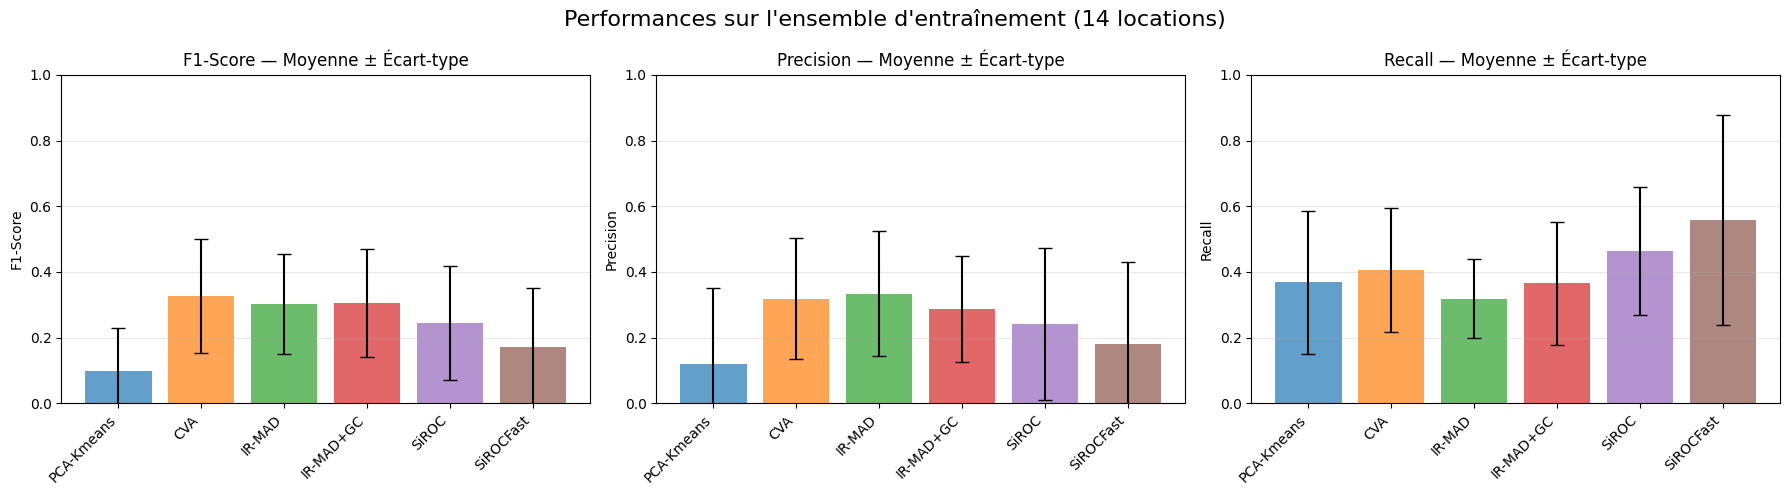

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performances sur l\'ensemble d\'entraînement (14 locations)', fontsize=16)

metrics_names = ['F1-Score', 'Precision', 'Recall']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes_flat[idx]
    means = df_train_summary[f'{metric} (mean)'].values
    stds = df_train_summary[f'{metric} (std)'].values
    methods = df_train_summary.index.tolist()

    x_pos = np.arange(len(methods))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(methods)] 
    ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Moyenne ± Écart-type')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Résultats Finaux

In [68]:
# Évaluation finale sur l'ensemble TEST (10 locations)

test_metrics, test_processed = process_locations(
    base_path,
    locations=TEST_LOCATIONS,
    methods_to_run=['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast'],
    label="TEST"
)

 TEST — 10 locations
Locations: ['brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w', 'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing']
Méthodes: ['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast']

[1/10] Traitement de : brasilia (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:00<00:00, 11.64it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:00<00:00, 11.61it/s]


SiROC...
SiROC (optimisé)...

[2/10] Traitement de : montpellier (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


...

SiROC...
SiROC (optimisé)...

[10/10] Traitement de : chongqing (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  5.94it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:02<00:00,  3.98it/s]


SiROC...
SiROC (optimisé)...


In [69]:
# Résultats agrégés sur l'ensemble TEST
df_test_summary = compute_aggregate_metrics(test_metrics)

print("\n" + "="*100)
print("RÉSULTATS FINAUX — ENSEMBLE DE TEST (10 locations)")
print("="*100)
print(df_test_summary.to_string())


RÉSULTATS FINAUX — ENSEMBLE DE TEST (10 locations)
            F1-Score (mean)  F1-Score (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  N images
PCA-Kmeans         0.199911        0.233844          0.192734         0.267696       0.462055      0.124854      10.0
CVA                0.346073        0.235490          0.371931         0.256144       0.381583      0.231316      10.0
IR-MAD             0.314791        0.180555          0.501103         0.341798       0.279371      0.144418      10.0
IR-MAD+GC          0.359912        0.231773          0.406168         0.294526       0.399321      0.189730      10.0
SiROC              0.319506        0.244992          0.311365         0.264988       0.447167      0.161222      10.0
SiROCFast          0.311811        0.254928          0.265770         0.242958       0.610466      0.220436      10.0


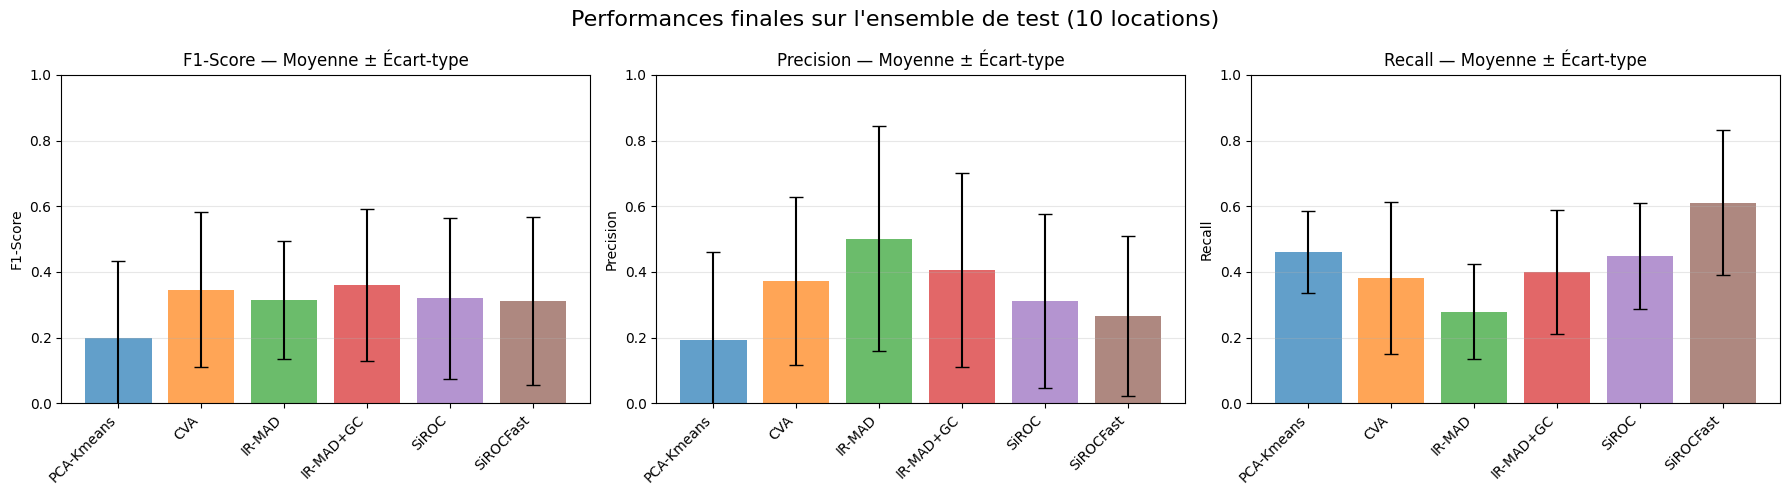

In [70]:
# Graphique comparatif Test — barres d'erreur
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performances finales sur l\'ensemble de test (10 locations)', fontsize=16)

metrics_names = ['F1-Score', 'Precision', 'Recall']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes_flat[idx]

    means = df_test_summary[f'{metric} (mean)'].values
    stds = df_test_summary[f'{metric} (std)'].values
    methods = df_test_summary.index.tolist()

    x_pos = np.arange(len(methods))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(methods)]
    ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Moyenne ± Écart-type')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

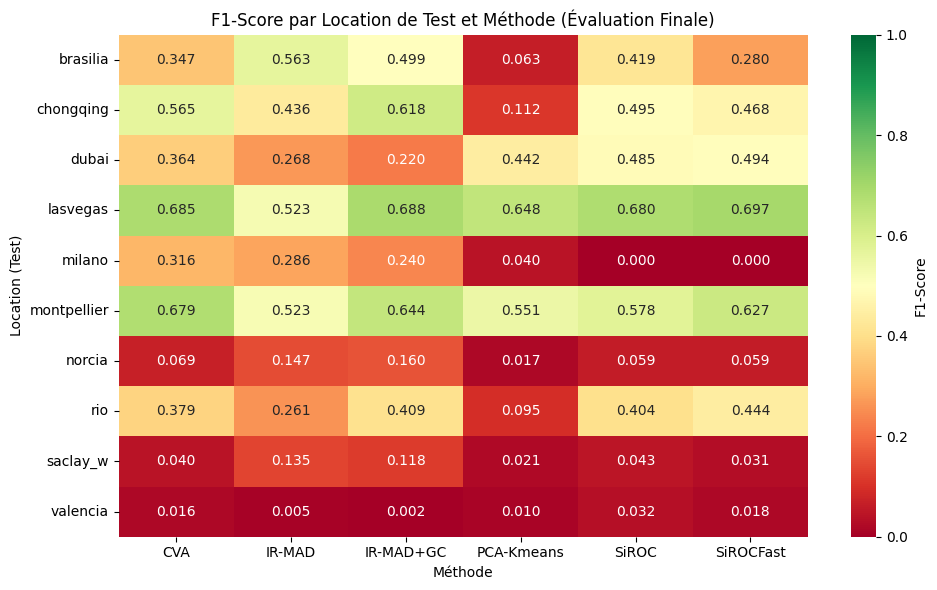

In [72]:
# Résultats détaillés par location
detailed_test_results = []
for method_name, metrics_list in test_metrics.items():
    for idx, metrics in enumerate(metrics_list):
        detailed_test_results.append({
            'Location': test_processed[idx],
            'Method': method_name,
            'F1-Score': metrics['F1-Score'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall']
        })

df_test_detailed = pd.DataFrame(detailed_test_results)

# Heatmap F1-Score par location de test et méthode
pivot_f1_test = df_test_detailed.pivot(index='Location', columns='Method', values='F1-Score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1_test, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score par Location de Test et Méthode (Évaluation Finale)')
plt.xlabel('Méthode')
plt.ylabel('Location (Test)')
plt.tight_layout()
plt.show()